<img src="./logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº5
#### Serena Saggion

# Introducción
En este trabajo práctico se estudia el contenido espectral de distintas señales reales mediante la estimación de su densidad espectral de potencia (PSD). Utilizando el método de Welch, se analiza la distribución de la potencia en función de la frecuencia y se estima el ancho de banda de cada señal, permitiendo comparar las características espectrales de señales fisiológicas y de audio.

# Teoría

## Densidad Espectral de Potencia (PSD)

La densidad espectral de potencia (Power Spectral Density, PSD) describe cómo se distribuye la potencia de una señal en función de la frecuencia. Su análisis permite identificar las frecuencias en las que la señal concentra la mayor parte de su energía, siendo una herramienta fundamental para caracterizar señales fisiológicas y de audio.

## Periodograma

El periodograma es uno de los métodos más simples para estimar la PSD de una señal a partir de un conjunto finito de muestras. Se obtiene calculando la Transformada Discreta de Fourier (DFT) de la señal y elevando al cuadrado el módulo de sus coeficientes.

Si x[n] es una señal de longitud N, el periodograma se define como
\begin{equation}P(\omega)=\frac{1}{N}\left|X(\omega)\right|^2\end{equation}
donde X(ω) es la DFT de la señal.

Aunque el periodograma es un estimador insesgado para señales largas, presenta una elevada varianza, por lo que suele generar estimaciones con importantes fluctuaciones.

## Método de Bartlett

El método de Bartlett busca reducir la varianza del periodograma. Para ello, divide la señal en varios segmentos no superpuestos de igual longitud. Luego calcula el periodograma de cada segmento y finalmente obtiene la PSD como el promedio de todos ellos.

Al realizar este promedio disminuye la variabilidad de la estimación, obteniéndose una PSD más estable. Sin embargo, al trabajar con segmentos más cortos también disminuye la resolución espectral.

## Método de Welch

El método de Welch constituye una mejora del método de Bartlett. En lugar de utilizar segmentos independientes, divide la señal en segmentos superpuestos, a los cuales además les aplica una función ventana (por ejemplo Hann o Hamming) antes de calcular el periodograma.

Finalmente, la PSD se obtiene promediando los periodogramas de todos los segmentos.

El uso de superposición y ventanas reduce aún más la varianza de la estimación sin degradar tanto la resolución espectral, razón por la cual el método de Welch es uno de los más utilizados para la estimación de densidad espectral de potencia en aplicaciones prácticas.

## Método de Blackman-Tukey

El método de Blackman-Tukey es una técnica de estimación de la densidad espectral de potencia basada en la función de autocorrelación de la señal. En primer lugar, se estima la autocorrelación a partir de un número finito de muestras y, posteriormente, se aplica una función ventana para limitar su longitud. Finalmente, la PSD se obtiene calculando la Transformada de Fourier de dicha autocorrelación.

A diferencia del periodograma, este método permite controlar el compromiso entre resolución espectral y varianza mediante la elección de la ventana y la longitud de la autocorrelación considerada. Sin embargo, su implementación resulta más compleja y, en aplicaciones prácticas, suele ser reemplazado por el método de Welch debido a su menor costo computacional y a la buena calidad de las estimaciones obtenidas.

## Estimación del ancho de banda mediante el criterio del 95%

Una vez obtenida la PSD, es posible estimar el ancho de banda de la señal. En este trabajo se empleó el criterio del 95% de la potencia acumulada, el cual consiste en calcular la potencia acumulada a partir de la PSD y determinar la frecuencia para la cual se alcanza el 95% de la potencia total.

Este criterio permite estimar el rango de frecuencias donde se concentra prácticamente toda la energía de la señal y resulta especialmente adecuado para comparar señales reales con contenidos espectrales diferentes, como señales fisiológicas y señales de audio.

## Señales analizadas

### Electrocardiograma (ECG)

El electrocardiograma (ECG) es una señal bioeléctrica que registra la actividad eléctrica del corazón a lo largo del tiempo. Su contenido espectral se concentra principalmente en bajas frecuencias; la mayor parte de la energía se encuentra entre aproximadamente 0.05 y 40 Hz, aunque para aplicaciones diagnósticas suelen considerarse frecuencias de hasta 100 Hz.

### Fotopletismografía (PPG)

La fotopletismografía (PPG) es una técnica óptica que permite medir las variaciones del volumen sanguíneo en los vasos periféricos mediante la detección de cambios en la absorción de luz. Se trata de una señal de muy baja frecuencia, cuya energía se concentra principalmente entre 0.5 y 10 Hz, dependiendo de la frecuencia cardíaca y de la presencia de componentes respiratorias.

### Voz humana

La voz humana es una señal acústica generada por la vibración de las cuerdas vocales y modulada por el tracto vocal. La frecuencia fundamental suele encontrarse entre 85 y 255 Hz, mientras que la mayor parte de la información necesaria para la inteligibilidad del habla se concentra aproximadamente entre 300 y 3400 Hz. Sin embargo, pueden existir componentes espectrales de mayor frecuencia asociadas a armónicos y consonantes.

# Procedimiento
Se realiza la estimación de la densidad espectral de potencia (PSD) de cada señal ECG, PPG y Audios mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey). Luego, se genera una estimación del ancho de banda de cada señal.

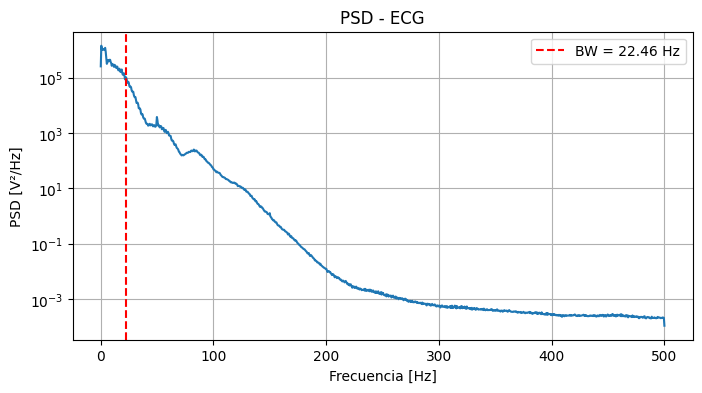

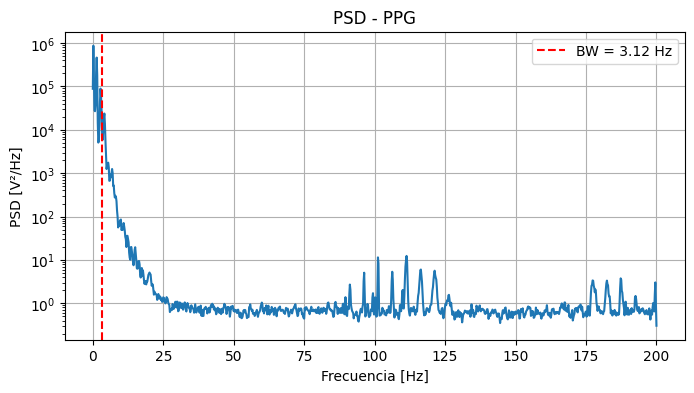

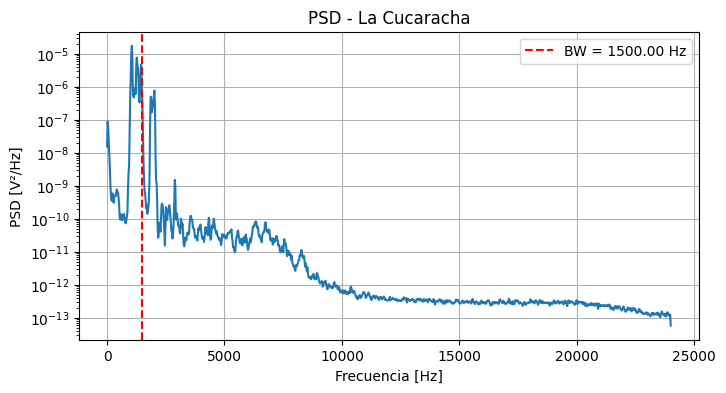

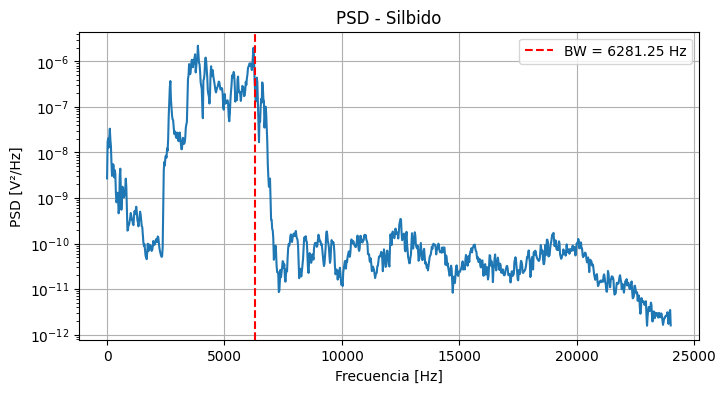



          Señal  Ancho de banda (95% potencia) [Hz]
0           ECG                           22.460938
1           PPG                            3.125000
2  La Cucaracha                         1500.000000
3       Silbido                         6281.250000


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import loadmat, wavfile



ruta_ecg = r"C:\Users\sere2\pdstestbench\ECG_TP4.mat"
ruta_ppg = r"C:\Users\sere2\pdstestbench\PPG.csv"
ruta_cuca = r"C:\Users\sere2\pdstestbench\la cucaracha.wav"
ruta_silb = r"C:\Users\sere2\pdstestbench\silbido.wav"


# FUNCIÓN PSD + ANCHO DE BANDA (95% potencia)

def calcular_psd_bw(x, fs, nombre):

    x = x - np.mean(x)

    # PSD mediante Welch
    f, PSD = signal.welch(
        x,
        fs=fs,
        window='hann',
        nperseg=2048
    )

    # Potencia acumulada
    P_acum = np.cumsum(PSD)

    # Potencia total
    P_total = P_acum[-1]

    # Normalización
    P_norm = P_acum / P_total

    # Frecuencia que contiene el 95% de la potencia
    indice = np.where(P_norm >= 0.95)[0][0]

    BW = f[indice]

    #-----------------------------
    # Gráfico
    #-----------------------------

    plt.figure(figsize=(8,4))

    plt.semilogy(f, PSD)

    plt.axvline(BW,
                color='red',
                linestyle='--',
                label=f'BW = {BW:.2f} Hz')

    plt.title(f'PSD - {nombre}')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [V²/Hz]')
    plt.grid(True)
    plt.legend()

    plt.show()

    return BW

# ECG

mat = loadmat(ruta_ecg)

ecg = mat["ecg_lead"].squeeze()

fs_ecg = 1000

BW_ecg = calcular_psd_bw(ecg, fs_ecg, "ECG")


# PPG

ppg = pd.read_csv(ruta_ppg)

senal_ppg = ppg.iloc[:,0].values

fs_ppg = 400

BW_ppg = calcular_psd_bw(senal_ppg,
                         fs_ppg,
                         "PPG")


# AUDIO

fs_audio, audio = wavfile.read(ruta_cuca)

if audio.ndim > 1:
    audio = audio[:,0]

BW_audio = calcular_psd_bw(audio,
                           fs_audio,
                           "La Cucaracha")

# SILBIDO


fs_silb, silb = wavfile.read(ruta_silb)

if silb.ndim > 1:
    silb = silb[:,0]

BW_silb = calcular_psd_bw(silb,
                          fs_silb,
                          "Silbido")



tabla = pd.DataFrame({

    "Señal":[
        "ECG",
        "PPG",
        "La Cucaracha",
        "Silbido"
    ],

    "Ancho de banda (95% potencia) [Hz]":[
        BW_ecg,
        BW_ppg,
        BW_audio,
        BW_silb
    ]

})

print("\n")
print(tabla)

# Analisis de Resultados
En primer lugar, se estimó la densidad espectral de potencia de cada señal mediante el método de Welch. A partir de las PSD obtenidas se observó que las señales fisiológicas, ECG y PPG, concentran la mayor parte de su potencia en bajas frecuencias. Esto es esperable, ya que ambas representan fenómenos biológicos de evolución lenta. En particular, el PPG presentó un espectro más concentrado en bajas frecuencias que el ECG, debido a que está asociado principalmente al pulso y a variaciones más lentas.

En cambio, las señales de audio presentaron un contenido espectral más amplio. La señal correspondiente a “La Cucaracha” mostró energía distribuida en un rango mayor de frecuencias, lo cual se relaciona con la presencia de componentes armónicas propias de la voz. El silbido presentó el mayor ancho de banda estimado, indicando una distribución de energía más extendida en frecuencia.

Para estimar el ancho de banda se utilizó el criterio del 95% de potencia acumulada.
Estos valores permiten comparar claramente las diferencias entre los tipos de señales. Las señales fisiológicas poseen anchos de banda reducidos, mientras que las señales de audio ocupan un rango frecuencial mucho mayor. Esto confirma que el ancho de banda depende directamente de la naturaleza de la señal y de la rapidez con la que varían sus componentes temporales.

# Conclusión
En este trabajo se estimó la densidad espectral de potencia de señales reales utilizando el método de Welch y, a partir de dicha estimación, se calculó el ancho de banda mediante el criterio del 95% de potencia acumulada.

Los resultados permitieron observar diferencias claras entre las señales fisiológicas y las señales de audio. El PPG presentó el menor ancho de banda, debido a que es una señal asociada a variaciones lentas del pulso. El ECG mostró un ancho de banda mayor, relacionado con componentes más rápidas de la actividad cardíaca. En cambio, las señales de audio presentaron un contenido espectral mucho más amplio, especialmente el silbido, que concentró energía en frecuencias más altas.

En conjunto, el análisis mostró que la **PSD** permite caracterizar la **distribución de potencia en frecuencia** y que el ancho de banda depende directamente de la naturaleza de la señal analizada.